# Rotating-mode spectrogram — DIII-D shot 174446

Demonstrates the MODESPEC-style pipeline from `magnetics.core.spectral`:

> **load → downsample → (optionally integrate) → compute spectrogram → de-noise → plot**

Two LFS-midplane Mirnov probes (`mpi66m307d` at φ=307°, `mpi66m340d` at φ=340°)
measure d*B*/d*t* at 200 kHz. Their toroidal separation Δφ = −33° lets us assign a
toroidal mode number *n* to each (time, frequency) cell from the cross-phase.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from magnetics.core.spectral import (
    compute_spectrogram,
    denoise_spectrogram,
    downsample,
)

# Point this at the hackathon_data directory containing magnetics_174446/
DATA_DIR = Path.home() / "hackathon_data"

## 1. Load the two probes

In [2]:
def load_probe(data_dir: Path, angle: int) -> dict:
    path = data_dir / f"magnetics_174446/174446_mpi66m{angle}d.npz"
    d = np.load(path, allow_pickle=True)
    return {
        "time_s": d["time_ms"].astype(np.float64) * 1e-3,
        "signal": d["signal"].astype(np.float64),
        "phi": float(angle),
        "fs": float(d["fs_hz"]),
    }


p1 = load_probe(DATA_DIR, 307)
p2 = load_probe(DATA_DIR, 340)
delta_phi = p1["phi"] - p2["phi"]  # -33 degrees

print(f"probe 1: φ={p1['phi']:.0f}°, {len(p1['signal'])} samples @ {p1['fs']*1e-3:.0f} kHz")
print(f"probe 2: φ={p2['phi']:.0f}°, {len(p2['signal'])} samples @ {p2['fs']*1e-3:.0f} kHz")
print(f"Δφ = {delta_phi:.0f}°")

probe 1: φ=307°, 2031616 samples @ 200 kHz
probe 2: φ=340°, 2031616 samples @ 200 kHz
Δφ = -33°


## 2. Downsample to the analysis window

Trim to 1500–3000 ms (where MHD activity is expected) and resample to 50 kHz —
enough to resolve modes up to 25 kHz.

In [3]:
t_range = (1.5, 3.0)  # seconds
t1, s1 = downsample(p1["time_s"], p1["signal"], t_range=t_range, sample_rate=50_000)
t2, s2 = downsample(p2["time_s"], p2["signal"], t_range=t_range, sample_rate=50_000)

print(f"downsampled to {len(s1)} samples over [{t1[0]*1e3:.0f}, {t1[-1]*1e3:.0f}] ms")

downsampled to 74999 samples over [1500, 3000] ms


## 3. Compute the spectrogram

A sliding 8 ms FFT window with 50% overlap. Each cell carries power, coherence,
and the cross-phase mode number *n*.

In [4]:
spec = compute_spectrogram(t1, s1, s2, delta_phi, slice_duration=0.008)
print(f"spectrogram: {spec.power.shape[0]} time slices × {spec.power.shape[1]} frequencies")
print(f"mode-number range resolved: {spec.mode_indices.min()} … {spec.mode_indices.max()}")

spectrogram: 373 time slices × 201 frequencies
mode-number range resolved: -5 … 5


## 4. De-noise

`denoise_spectrogram` removes low-amplitude / incoherent cells two ways:

1. **Coherence gate** — drop cells where the two probes are incoherent (no real mode).
2. **Per-frequency power floor** — drop cells below `k × median(power)` at each frequency.

Gated cells get power 0 and `rms_by_mode` is recomputed from what survives. Note the
floor assumes modes are *transient*; a perfectly persistent mode raises its own
per-frequency median, so lean on the coherence gate for steady/locked modes.

In [5]:
clean = denoise_spectrogram(spec, coherence_min=0.5, power_floor_k=3.0)

raw_nz = np.count_nonzero(spec.power)
clean_nz = np.count_nonzero(clean.power)
print(f"cells kept: {clean_nz}/{raw_nz} ({100*clean_nz/raw_nz:.0f}%)")
print(f"power retained: {100*clean.power.sum()/spec.power.sum():.0f}%")

cells kept: 15287/74973 (20%)
power retained: 98%


## 5. Plot — raw vs. de-noised

Left column raw, right column de-noised. Top row log power, bottom row toroidal
mode number (masked to cells with surviving power).

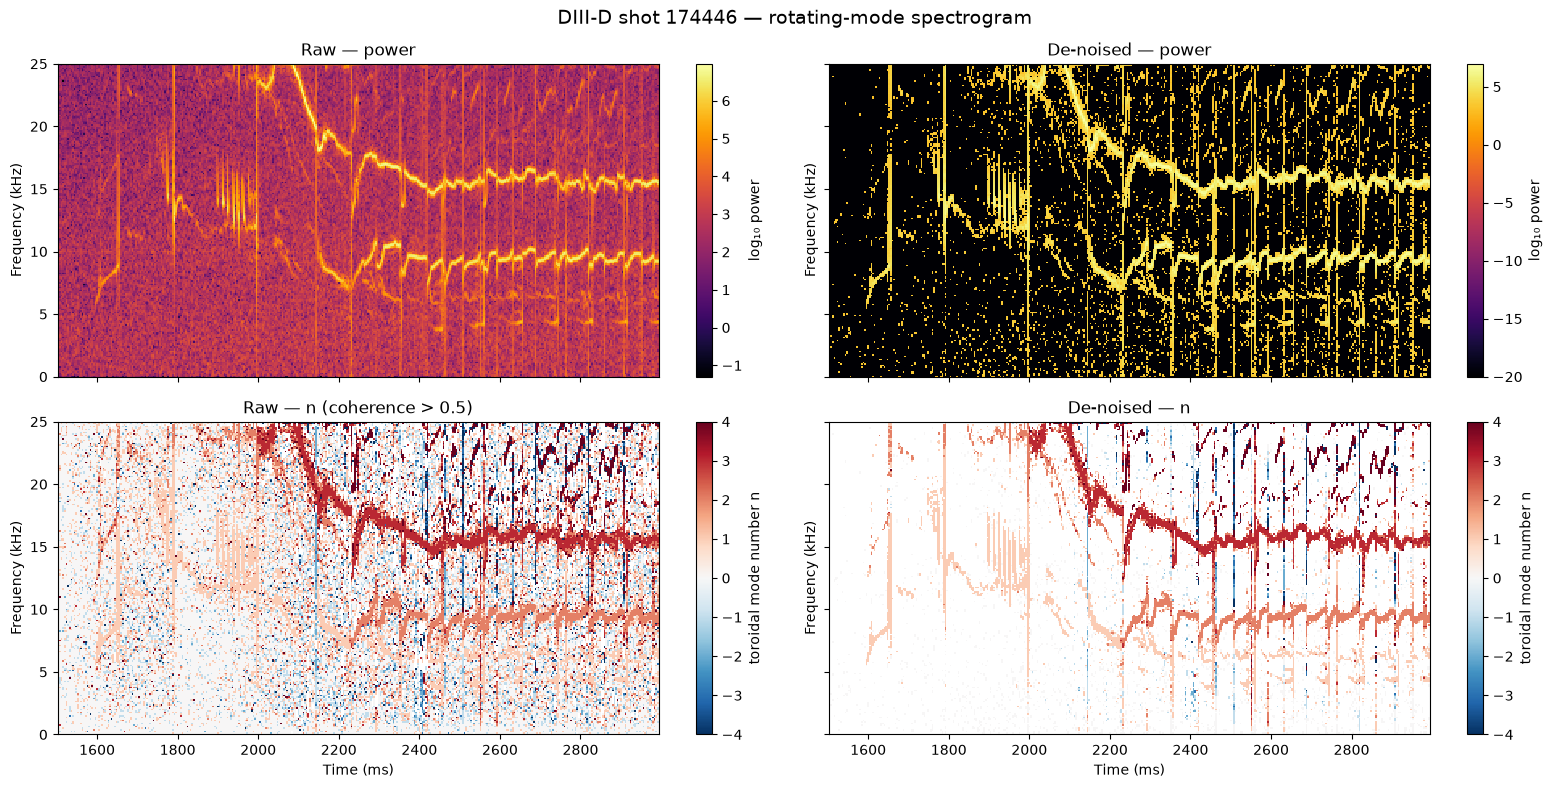

In [6]:
def power_panel(ax, sp, title):
    pc = ax.pcolormesh(
        sp.time * 1e3,
        sp.frequency * 1e-3,
        np.log10(sp.power.T + 1e-20),
        shading="auto",
        cmap="inferno",
    )
    fig.colorbar(pc, ax=ax, label="log₁₀ power")
    ax.set_ylabel("Frequency (kHz)")
    ax.set_title(title)
    ax.set_ylim(0, 25)


def mode_panel(ax, sp, title, *, mask):
    mode_plot = np.where(mask.T, sp.mode_number.T.astype(float), np.nan)
    pc = ax.pcolormesh(
        sp.time * 1e3,
        sp.frequency * 1e-3,
        mode_plot,
        shading="auto",
        cmap="RdBu_r",
        vmin=-4,
        vmax=4,
    )
    fig.colorbar(pc, ax=ax, label="toroidal mode number n")
    ax.set_ylabel("Frequency (kHz)")
    ax.set_xlabel("Time (ms)")
    ax.set_title(title)
    ax.set_ylim(0, 25)


fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True, sharey=True)

power_panel(axes[0, 0], spec, "Raw — power")
power_panel(axes[0, 1], clean, "De-noised — power")

# raw mode panel: gate on coherence; de-noised: gate on surviving power
mode_panel(axes[1, 0], spec, "Raw — n (coherence > 0.5)", mask=spec.coherence > 0.5)
mode_panel(axes[1, 1], clean, "De-noised — n", mask=clean.power > 0)

fig.suptitle("DIII-D shot 174446 — rotating-mode spectrogram", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Focused test — engine & physics

A self-contained regression check of the batched-STFT engine on the active-mode
window: the output-shape contract, the `max_columns` decimation lever, DC suppression
from per-window detrend, recovery of the 2/1-class fundamental (`|n| = 2`) at the
strongest cell, sign-agreement with the trusted single-window `cross_spectrum`, and the
`Δφ = 0` guard. Raises `AssertionError` if anything regresses.

In [7]:
import time

from magnetics.core.spectral import cross_spectrum

# Active-mode window at the full 200 kHz rate (exercises the decimation lever).
m = (p1["time_s"] >= 2.3) & (p1["time_s"] <= 3.0)
tt, a1, a2 = p1["time_s"][m], p1["signal"][m], p2["signal"][m]
fs = 1.0 / np.median(np.diff(tt))

t0 = time.perf_counter()
r = compute_spectrogram(tt, a1, a2, delta_phi, slice_duration=1e-3, max_columns=1500)
elapsed_ms = (time.perf_counter() - t0) * 1e3

# 1. shape contract + finiteness
n_t, n_f = r.power.shape
assert r.coherence.shape == (n_t, n_f)
assert r.mode_number.shape == (n_t, n_f)
assert r.rms_by_mode.shape == (n_t, r.mode_indices.size)
assert np.all(np.isfinite(r.power)) and np.all(np.isfinite(r.coherence))

# 2. decimation lever respected
assert n_t <= 1500

# 3. per-window detrend suppresses DC: the f=0 bin sits below the mode band
dc = r.power[:, 0].mean()
band = r.power[:, (r.frequency >= 5e3) & (r.frequency <= 25e3)].mean()
assert dc < band, f"DC bin ({dc:.2e}) should be below the mode band ({band:.2e})"

# 4. physics: the strongest off-DC cell is the 2/1-class fundamental, |n| = 2
power_offdc = r.power.copy()
power_offdc[:, r.frequency < 3e3] = 0.0
it, iff = np.unravel_index(np.argmax(power_offdc), power_offdc.shape)
n_peak = int(r.mode_number[it, iff])
assert abs(n_peak) == 2, f"expected |n| = 2 at the peak, got {n_peak}"

# 5. the fast engine agrees in sign with the trusted single-window cross_spectrum
cs = cross_spectrum(a1, a2, fs, delta_phi=delta_phi)
cs_offdc = cs.power.copy()
cs_offdc[cs.frequency < 3e3] = 0.0
n_ref = int(cs.mode_number[np.argmax(cs_offdc)])
assert n_peak == n_ref, f"engine n={n_peak} disagrees with cross_spectrum n={n_ref}"

# 6. Δφ = 0 guard
try:
    compute_spectrogram(tt, a1, a2, 0.0)
    raise AssertionError("Δφ = 0 must raise ValueError")
except ValueError:
    pass

print(f"OK — {n_t}×{n_f} grid from {a1.size:,} samples in {elapsed_ms:.1f} ms")
print(f"peak cell n = {n_peak} (matches cross_spectrum); DC {dc:.1e} < band {band:.1e}")

OK — 1399×101 grid from 140,001 samples in 12.7 ms
peak cell n = 2 (matches cross_spectrum); DC 2.3e+03 < band 1.3e+05


## 7. Revised spectrogram — OMFIT physics on the pyspec engine

The same four-panel layout, colour scheme, and parameters as section 5, recomputed
through the revised engine: the **pyspec** batched single-precision STFT plus the
**OMFIT** physics (per-window DC-detrend, coherence gate, and the sign-corrected toroidal
mode number). Reuses section 5's downsampled signals and `power_panel` / `mode_panel`
helpers so the styling is identical — the de-noised column isolates the rotating 2/1 mode
chirping down, with `n` reading cleanly on the fundamental and its harmonic.

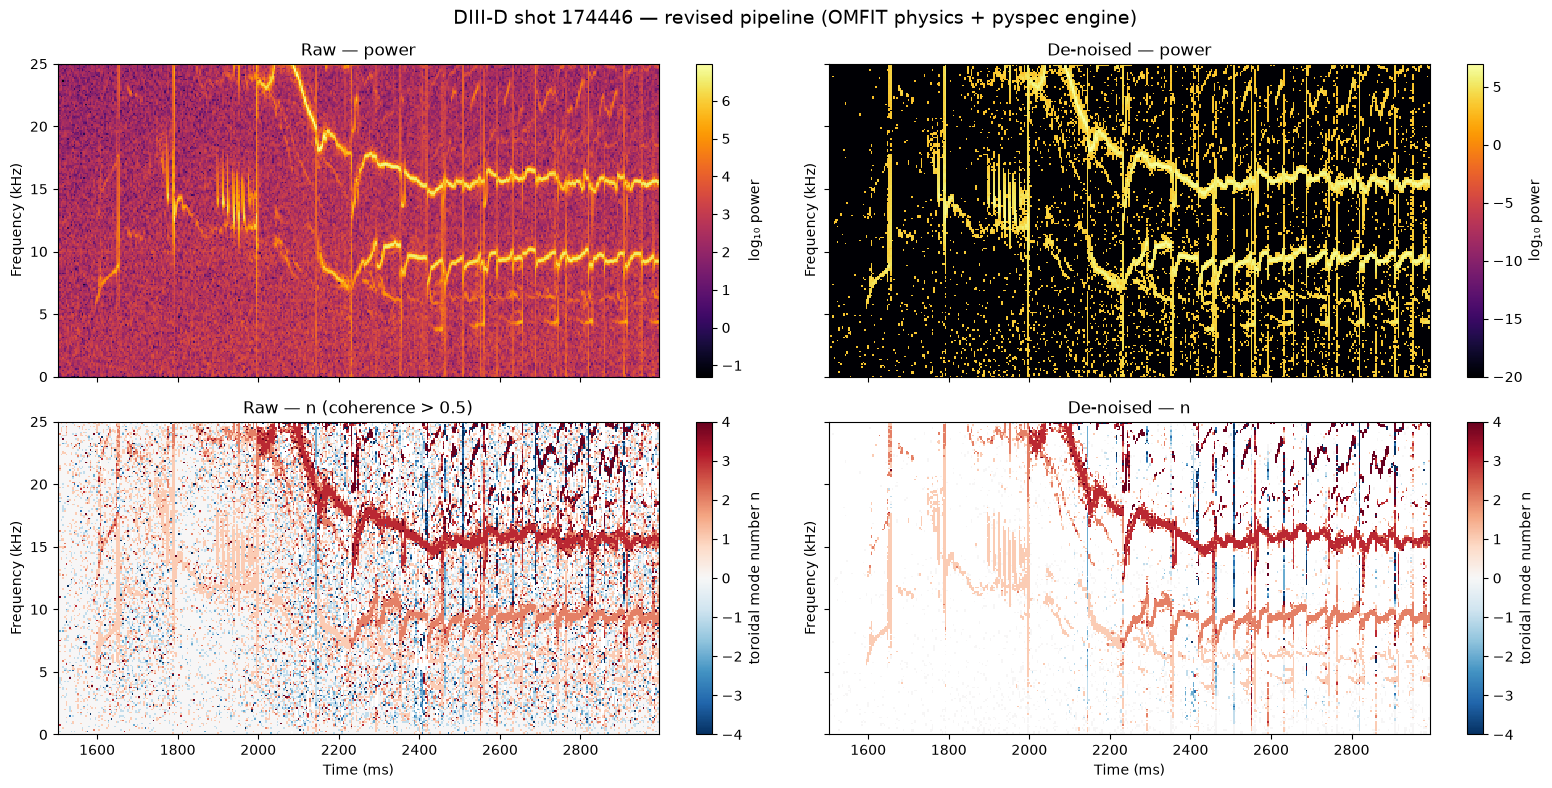

grid: 373 time × 201 freq
peak-rms mode number over the de-noised band: n = 3


In [9]:
# Same module-5 settings and colour scheme, recomputed through the revised engine
# (DC-detrend + sign-corrected n). Reuses the section-5 downsampled signals (t1, s1, s2)
# and the power_panel / mode_panel helpers so styling and parameters are identical.
rev = compute_spectrogram(t1, s1, s2, delta_phi, slice_duration=0.008)
rev_clean = denoise_spectrogram(rev, coherence_min=0.5, power_floor_k=3.0)

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True, sharey=True)

power_panel(axes[0, 0], rev, "Raw — power")
power_panel(axes[0, 1], rev_clean, "De-noised — power")

mode_panel(axes[1, 0], rev, "Raw — n (coherence > 0.5)", mask=rev.coherence > 0.5)
mode_panel(axes[1, 1], rev_clean, "De-noised — n", mask=rev_clean.power > 0)

fig.suptitle(
    "DIII-D shot 174446 — revised pipeline (OMFIT physics + pyspec engine)",
    fontsize=14,
)
plt.tight_layout()
plt.show()

print(f"grid: {rev.power.shape[0]} time × {rev.power.shape[1]} freq")
print(
    "peak-rms mode number over the de-noised band: "
    f"n = {int(rev.mode_indices[np.argmax(rev_clean.rms_by_mode.sum(0))])}"
)